# NUTS sampling evaluation

In [104]:
# import the data
import pickle

with open("NUTS_generated_data.pkl", "rb") as f:
    NUTS_chains = pickle.load(f)

with open("precision_matrix.pkl", "rb") as f:
    prec_mat = pickle.load(f)

with open("mu_i.pkl", "rb") as f:
    mu = pickle.load(f)

In [105]:
mu

array([-0.1199169 , -0.04092178, -0.01293869, -0.02496403,  0.02832858,
        0.03973839,  0.00802261, -0.03740088,  0.06419321,  0.05773572],
      dtype=float32)

In [72]:
NUTS_chains[0,1000:2000].shape

(1000, 10)

In [95]:
NUTS_data_2D = NUTS_chains.reshape(-1, NUTS_chains.shape[-1])
NUTS_data_2D_warm_up = np.concatenate(
    [NUTS_data_2D[1000:2000], NUTS_data_2D[3000:4000]],
    axis=0
)

## Kolmogorov-Smirnov test
https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

The Kolmogorov-Smirnov test is suitable only for 1D distributions, so let's use it to evaluate the distributions of the sampled data along the single directions. In this way we can evaluate how much every single variable empirical distribution is far/near the theoretical one. Here I performed only the KS-test to verify if the distribution of a single chain comes from the theoretical gaussian distribuiton adopted to generate them via NUTS. We can also use the KS-test to check if two chains come from the same distribution...
Start looking at the single variable data sampled with NUTS:

In [96]:
def single_variable_dist(data):
    d = data.shape[1]
    rows, cols = 5, 2

    fig, axes = plt.subplots(rows, cols, figsize=(10, 20))
    axes = axes.flatten()

    for i in range(rows*cols):
        ax = axes[i]

        ax.hist(data[:,i], bins=30, edgecolor='black')

        ax.set_title(f"Dim {i} distribution")
        ax.set_xlabel(f"X_{i}")
        ax.set_ylabel("Counts")
        ax.grid(True)

    # Rimuovi subplot vuoti (se d < 10)
    for j in range(d, rows*cols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


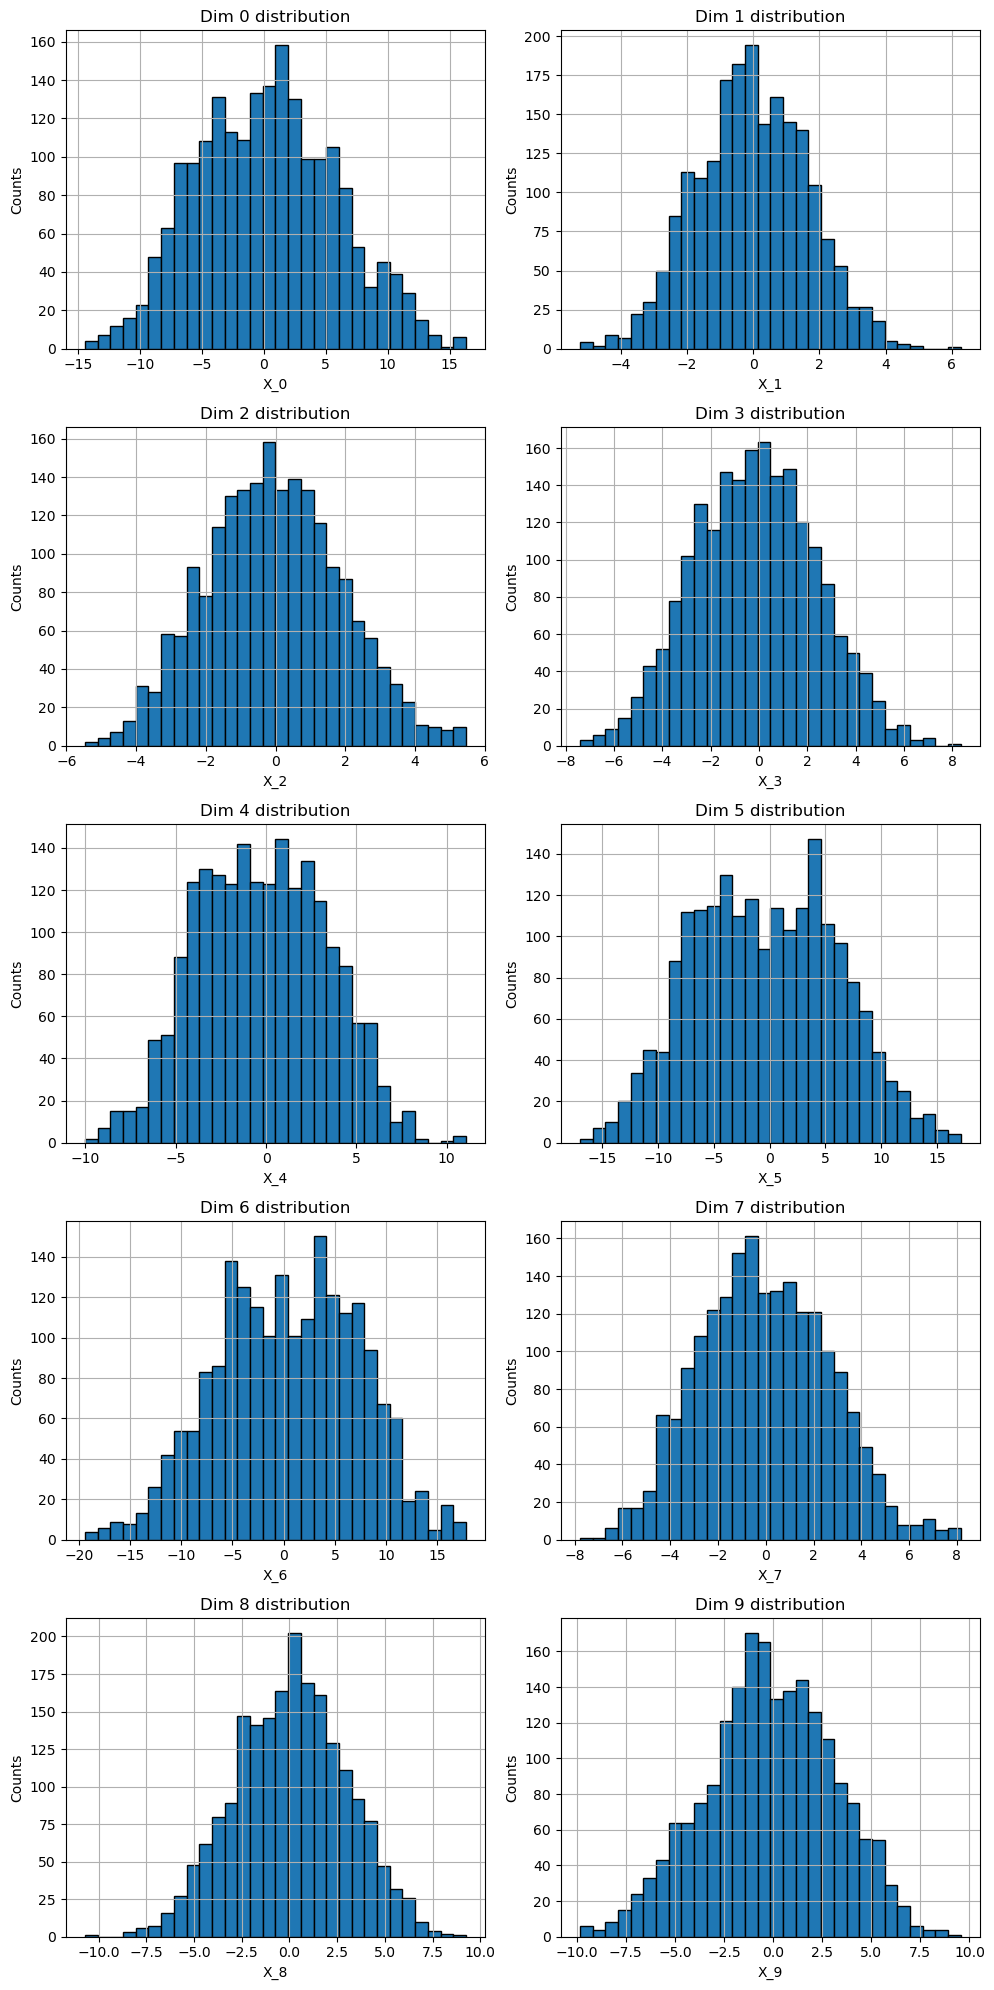

In [97]:
single_variable_dist(NUTS_data_2D_warm_up)

In [98]:
# For now work only on the first chain, then generalize for n chains...
from scipy.stats import kstest, norm

# y = 1D samples (j-th component)
stats = []
pvals = []

for j in range(D-1):
    stat, pval = kstest(NUTS_data_2D_warm_up[:,j], 'norm', args=(0, 1))
    stats.append(float(stat))
    pvals.append(float(pval))
    

print("KS statistic: \n", stats, "\n")
print("p-value: \n", pvals, "\n")


KS statistic: 
 [0.3473997561715402, 0.13853080475292506, 0.17245988656993433, 0.24436679823417318, 0.32703375672990276, 0.4024625472200075, 0.4202582414492926, 0.24814734212645181, 0.25581025319814943] 

p-value: 
 [3.5395408944652e-216, 6.06695494138153e-34, 1.744142397927276e-52, 1.2098505970038747e-105, 5.5439632449203514e-191, 5.176976971541644e-293, 1.1334e-320, 5.697902786549294e-109, 7.014131746061513e-116] 



In the test we have:

$$
H_0 : \text{the sample follows the theoretical distribution} \ F(x)
H_1 : \text{the sample comes from another distribution} 
$$

The $p-value$ tells us how confident we are in accepting $H_0$. Hence, with a such small values we reject the $H_0$ hypotesis.

This is what we expect if we don't perform a whightening procedure on the data. The Whitening is a procedure to transport our data in another space where they follow a gaussian distribution with mean 0. So, let's do the same but with the whitening procedure.

In [99]:
from scipy.linalg import cholesky
import matplotlib.pyplot as plt

#Functions to perform the KStest

# ---------------------------------------------------------
# Whitening
# ---------------------------------------------------------

def whiten_from_precision(samples, mu, precision):
    """
    samples: (N, d)
    mu: (d,)
    precision: (d, d)  # precison matrix A
    """
    x_c = samples - mu
    R = cholesky(precision, lower=False)  # A = R^T R
    y = x_c @ R.T  # y = R x_c
    return y
    

# ---------------------------------------------------------
# KS test on each dimension
# ---------------------------------------------------------

def ks_marginals(whitened):
    d = whitened.shape[1]
    results = []
    for i in range(d):
        stat, pval = kstest(whitened[:, i], 'norm', args=(0, 1))
        results.append((i, stat, pval))
    return results

# ---------------------------------------------------------
# QQ‑plots 
# ---------------------------------------------------------

def qq_plot_dimension(whitened, dim):
    plt.figure(figsize=(5, 5))
    sorted_data = np.sort(whitened[:, dim])
    quantiles = norm.ppf(np.linspace(0.001, 0.999, len(sorted_data)))
    plt.plot(quantiles, sorted_data, 'o', markersize=3)
    plt.plot(quantiles, quantiles, 'r--')
    plt.xlabel("Quantili teorici N(0,1)")
    plt.ylabel("Quantili empirici")
    plt.title(f"QQ‑plot dimensione {dim}")
    plt.grid(True)
    plt.show()


In [100]:
# Functions to compute the SSE

def autocorrelation_fft(x):
    """
    Autocorrelation via FFT (O(n log n)).
    """
    x = np.asarray(x)
    n = len(x)
    x = x - np.mean(x)
    fft = np.fft.fft(x, n*2)
    acf = np.fft.ifft(fft * np.conjugate(fft))[:n].real
    acf /= acf[0]
    return acf

def ess_1d(x):
    """
    Effective Sample Size for a 1D MCMC chain using Geyer's initial positive sequence.
    """
    acf = autocorrelation_fft(x)
    s = 0.0
    for k in range(1, len(acf)-1, 2):
        pair = acf[k] + acf[k+1]
        if pair < 0:
            break
        s += pair
    ess = len(x) / (1 + 2*s)
    return ess

def ess_all_dims(samples):
    """
    samples: (N, d)
    Returns ESS for each dimension.
    """
    N, d = samples.shape
    ess = np.zeros(d)
    for i in range(d):
        ess[i] = ess_1d(samples[:, i])
    return ess


In [101]:
eff_samp_size = ess_all_dims(NUTS_chains[0])
print(eff_samp_size)

[413.67501831 771.66809082 492.51974487 388.7427063  246.98324585
 243.94429016 267.85809326 527.68511963 644.39764404 438.4883728 ]


In [102]:
# put all the qq-plots toghether
from scipy.stats import norm

def qq_plot_all_dimensions(whitened, ess_values):
    d = whitened.shape[1]
    rows, cols = 5, 2

    fig, axes = plt.subplots(rows, cols, figsize=(10, 20))
    axes = axes.flatten()

    for i in range(d):
        ax = axes[i]

        sorted_data = np.sort(whitened[:, i])
        quantiles = norm.ppf(np.linspace(0.001, 0.999, len(sorted_data)))

        ax.plot(quantiles, sorted_data, 'o', markersize=2)
        ax.plot(quantiles, quantiles, 'r--')

        ax.set_title(f"Dim {i} — ESS={ess_values[i]:.1f}")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles")
        ax.grid(True)

    # Remove empty subplots if  d < 10
    for j in range(d, rows*cols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [107]:
# Prepare the data
whitened_sample = whiten_from_precision(NUTS_data_2D_warm_up, mu, prec_mat)

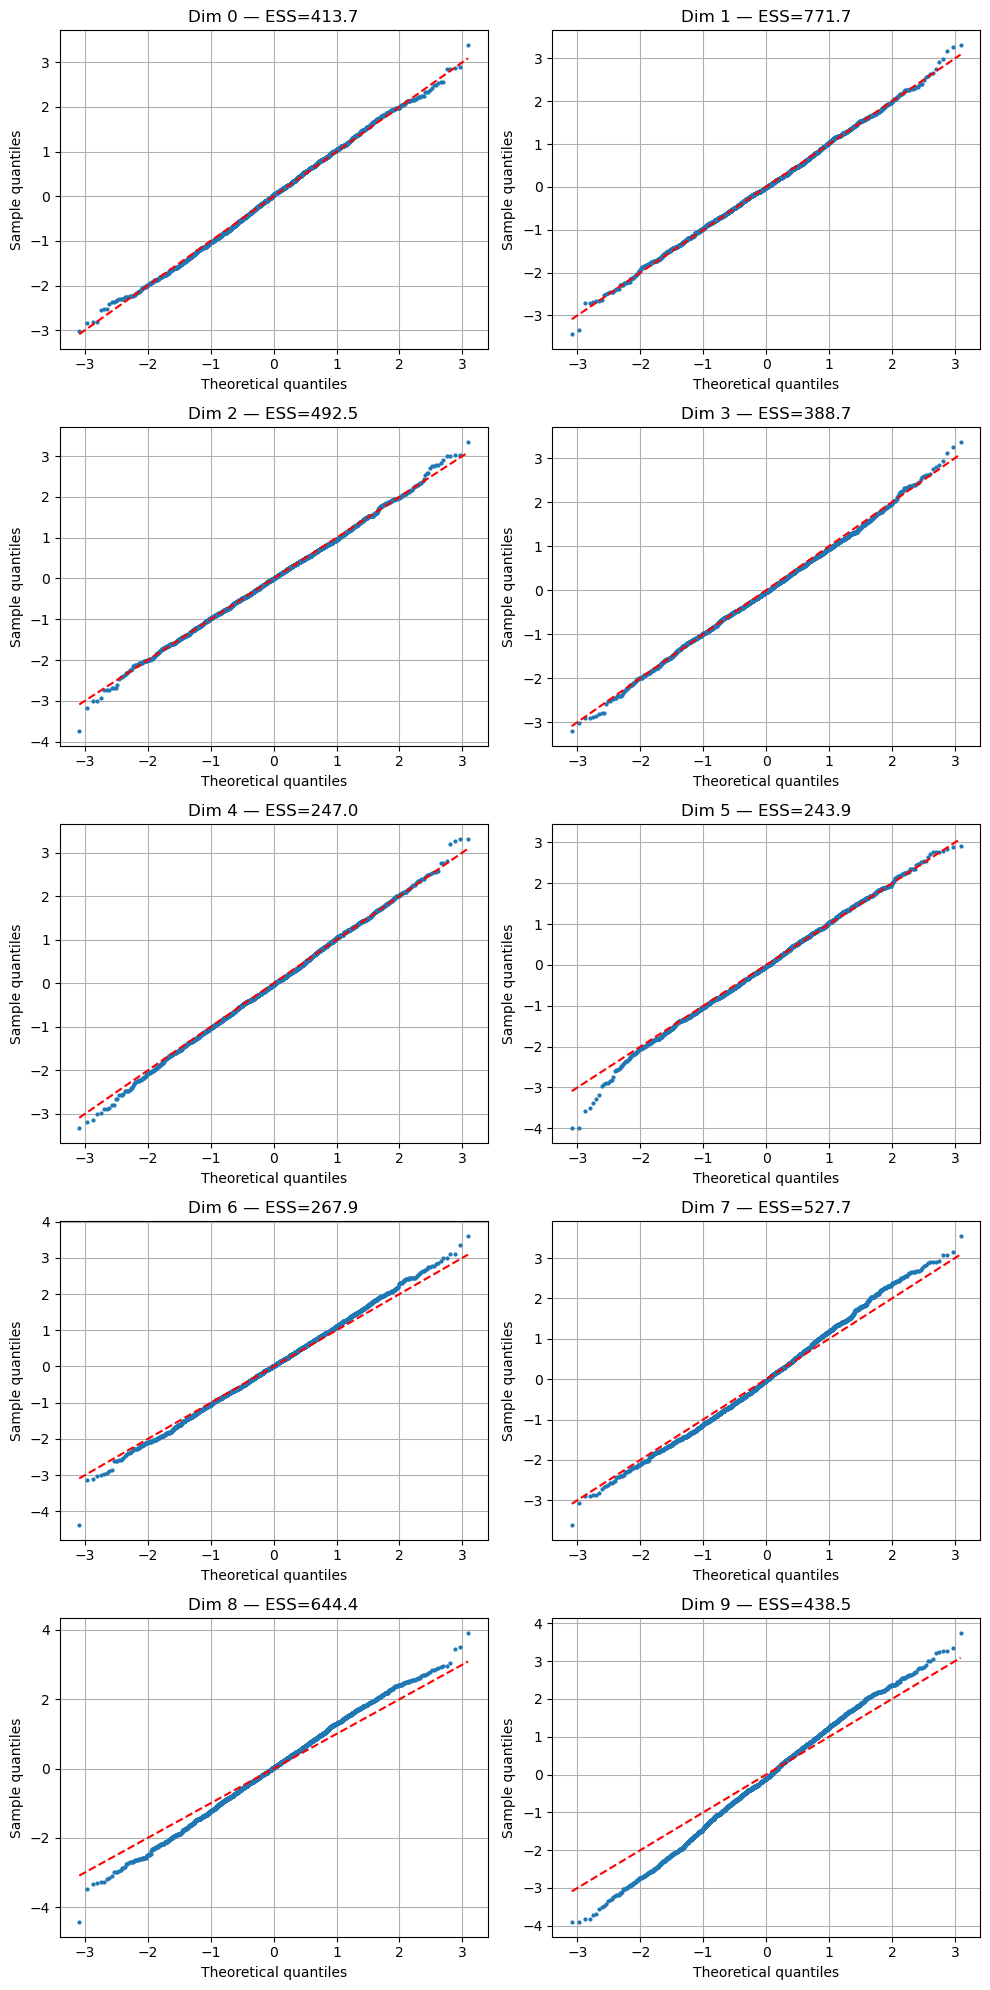

In [108]:
qq_plot_all_dimensions(whitened_sample, eff_samp_size)

In [113]:
ks_marginals(whitened_sample)

[(0, np.float64(0.018881872384865717), np.float64(0.4681743266881768)),
 (1, np.float64(0.01517082027897032), np.float64(0.7407197470329625)),
 (2, np.float64(0.01564511506193389), np.float64(0.7056408106551167)),
 (3, np.float64(0.021543186920637947), np.float64(0.3068830869102449)),
 (4, np.float64(0.01969067393257451), np.float64(0.4147716006353873)),
 (5, np.float64(0.022190478259131563), np.float64(0.2741970660107398)),
 (6, np.float64(0.027400649800449095), np.float64(0.09743321939677174)),
 (7, np.float64(0.04338042817963972), np.float64(0.0010431098501412254)),
 (8, np.float64(0.06867105885722202), np.float64(1.2061194750973181e-08)),
 (9, np.float64(0.08378683138220097), np.float64(1.1576779223405578e-12))]

## Energy Distance Test 
It is a test for multivariate distributions to check if a sample comes from a given multidimensional distribution. See the article added in this directory.

In [114]:
# ---------------------------------------------------------
#Energy Distance Test (multivariate)
# ---------------------------------------------------------

def energy_distance(X, Y):
    """
    Compute the energy distance between two samples X and Y.
    X: (n, d)
    Y: (m, d)
    """
    n, d = X.shape
    m, _ = Y.shape

    # pairwise distances
    XY = np.linalg.norm(X[:, None, :] - Y[None, :, :], axis=2)
    XX = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    YY = np.linalg.norm(Y[:, None, :] - Y[None, :, :], axis=2)

    return 2 * XY.mean() - XX.mean() - YY.mean()


def energy_test_whitened(whitened, n_ref=2000, n_perm=200):
    """
    whitened: (N, d) samples whitened to N(0, I)
    n_ref: number of reference samples from N(0, I)
    n_perm: number of permutations for p-value
    """
    N, d = whitened.shape

    # reference theoretical samples
    Z = np.random.randn(n_ref, d)

    # observed statistic
    T_obs = energy_distance(whitened, Z)

    # permutation test
    T_perm = []
    combined = np.vstack([whitened, Z])
    total = combined.shape[0]

    for _ in range(n_perm):
        idx = np.random.permutation(total)
        Xp = combined[idx[:N]]
        Yp = combined[idx[N:]]
        T_perm.append(energy_distance(Xp, Yp))

    T_perm = np.array(T_perm)

    # p-value: fraction of permuted stats >= observed
    p_value = np.mean(T_perm >= T_obs)

    return T_obs, p_value


In [115]:
T, p = energy_test_whitened(NUTS_data_2D_warm_up)

print(f"Energy Distance statistic: {T:.4f}")
print(f"p-value: {p:.4f}")


Energy Distance statistic: 3.8649
p-value: 0.0000


In [116]:
def energy_test_no_whitening(samples, mu, precision, n_ref=2000, n_perm=200):
    """
    Energy Distance test directly on original samples.
    samples: (N, d)
    mu: (d,)
    precision: (d, d) precision matrix A
    """
    N, d = samples.shape

    # theoretical covariance
    Sigma = np.linalg.inv(precision)

    # generate reference samples from N(mu, Sigma)
    Z = np.random.multivariate_normal(mu, Sigma, size=n_ref)

    # compute observed statistic
    T_obs = energy_distance(samples, Z)

    # permutation test
    combined = np.vstack([samples, Z])
    total = combined.shape[0]
    T_perm = []

    for _ in range(n_perm):
        idx = np.random.permutation(total)
        Xp = combined[idx[:N]]
        Yp = combined[idx[N:]]
        T_perm.append(energy_distance(Xp, Yp))

    T_perm = np.array(T_perm)
    p_value = np.mean(T_perm >= T_obs)

    return T_obs, p_value


In [117]:
mu = np.zeros(10)  # media teorica
T2, p2 = energy_test_no_whitening(NUTS_data_2D, mu, prec_mat)

print("Energy Distance (no whitening):", T2)
print("p-value:", p2)



Energy Distance (no whitening): 0.27329109100971394
p-value: 0.0


# KL-Divergence
